# DC Traffic Camera Impact Analysis — Walkthrough

This notebook is the narrated version of the analysis pipeline in `scripts/`. It runs the same code but with explanation between each step, so you can read through it top to bottom and understand what the analysis does and why each decision was made.

**The question:** Did DC's automated traffic enforcement cameras actually make their surrounding blocks safer?

**The approach:** For every active camera, count crashes within a 200-meter buffer in the year before installation and the year after. Compare that change to the citywide crash trend over the same windows. The *difference* between those two changes — the difference-in-differences — is what we're actually measuring.

**What you need to run this:**
- Python 3.10+
- Packages in `requirements.txt` (install with `pip install -r requirements.txt`)
- The raw Excel file in `data/raw/Midterm_Memo.xlsx`

Let's go.

## Setup

Standard imports. `pandas` and `numpy` do the data munging, `sklearn.neighbors.BallTree` does the spatial index, and `matplotlib` handles the figures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree
from pathlib import Path

# Paths relative to the notebook location
RAW = Path("../data/raw/Midterm_Memo.xlsx")

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

## Step 1 — Clean the crash data

The DDOT crash dataset has 90,941 rows and 66 columns. Most of the columns are noise for our purposes; we only need the date, the coordinates, and the injury/severity flags.

The cleaning rules are:
- **Valid date** in 2021–2026 (a surprising number of rows have dates like `1900-02-07`, which is an Excel epoch artifact from time-only fields)
- **Coordinates inside the DC bounding box** (lat 38.79–39.00, lon −77.12 to −76.91)
- **Numeric coercion with `errors='coerce'`** on every field that should be a number — turns bad values into NaN instead of crashing the script

After filtering, we add severity flags: `is_fatal`, `is_major`, `is_minor`, plus a combined `is_injury` (any of the three) and `is_serious` (fatal or major). The headline metric in this analysis is injury crashes — they're common enough to be statistically meaningful and serious enough to matter.

In [2]:
USECOLS = [
    'REPORTDATE', 'LATITUDE', 'LONGITUDE', 'WARD', 'SPEEDING_INVOLVED',
    'FATAL_DRIVER', 'FATAL_PEDESTRIAN', 'FATAL_BICYCLIST', 'FATALPASSENGER', 'FATALOTHER',
    'MAJORINJURIES_DRIVER', 'MAJORINJURIES_PEDESTRIAN', 'MAJORINJURIES_BICYCLIST',
    'MAJORINJURIESPASSENGER', 'MAJORINJURIESOTHER',
    'MINORINJURIES_DRIVER', 'MINORINJURIES_PEDESTRIAN', 'MINORINJURIES_BICYCLIST',
    'MINORINJURIESPASSENGER', 'MINORINJURIESOTHER',
]

FATAL_COLS = ['FATAL_DRIVER','FATAL_PEDESTRIAN','FATAL_BICYCLIST','FATALPASSENGER','FATALOTHER']
MAJOR_COLS = ['MAJORINJURIES_DRIVER','MAJORINJURIES_PEDESTRIAN','MAJORINJURIES_BICYCLIST','MAJORINJURIESPASSENGER','MAJORINJURIESOTHER']
MINOR_COLS = ['MINORINJURIES_DRIVER','MINORINJURIES_PEDESTRIAN','MINORINJURIES_BICYCLIST','MINORINJURIESPASSENGER','MINORINJURIESOTHER']

print("Loading raw crash data...")
df = pd.read_excel(RAW, sheet_name='Crash_Raw', usecols=USECOLS)
print(f"  Raw rows: {len(df):,}")

# Coerce types
df['REPORTDATE'] = pd.to_datetime(df['REPORTDATE'], errors='coerce').dt.normalize()
df['LATITUDE'] = pd.to_numeric(df['LATITUDE'], errors='coerce')
df['LONGITUDE'] = pd.to_numeric(df['LONGITUDE'], errors='coerce')
for c in FATAL_COLS + MAJOR_COLS + MINOR_COLS + ['SPEEDING_INVOLVED']:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

# Filter
mask = (df['REPORTDATE'].between('2021-01-01','2026-12-31')
        & df['LATITUDE'].between(38.79, 39.00)
        & df['LONGITUDE'].between(-77.12, -76.91))
df = df[mask].copy()

# Severity flags
df['is_fatal'] = df[FATAL_COLS].sum(axis=1) > 0
df['is_major'] = df[MAJOR_COLS].sum(axis=1) > 0
df['is_minor'] = df[MINOR_COLS].sum(axis=1) > 0
df['is_injury'] = df['is_fatal'] | df['is_major'] | df['is_minor']
df['is_serious'] = df['is_fatal'] | df['is_major']
df['is_speeding'] = df['SPEEDING_INVOLVED'] > 0

crashes = df[['REPORTDATE','LATITUDE','LONGITUDE','WARD',
              'is_fatal','is_major','is_minor','is_injury','is_serious','is_speeding']].reset_index(drop=True)

print(f"  Clean crashes: {len(crashes):,}")
print(f"  Injury crashes: {crashes['is_injury'].sum():,}")
print(f"  Serious (fatal + major): {crashes['is_serious'].sum():,}")
print(f"  Fatal: {crashes['is_fatal'].sum():,}")

Loading raw crash data...


  Raw rows: 90,941
  Clean crashes: 75,400
  Injury crashes: 18,892
  Serious (fatal + major): 1,353
  Fatal: 150


## Step 2 — Filter to eligible cameras

Not every camera in the dataset is usable. To measure a clean before/after effect, we need:

1. **Live enforcement status** — drops Warning and Test cameras where enforcement isn't real
2. **Full 365-day pre-install window** inside the crash data (install must be at least 1 year after earliest crash)
3. **Full 365-day post-install window** inside the crash data (install must be at least 1 year before latest crash)

That third rule is the one that drops the most cameras. DC has been installing cameras aggressively in 2024–2025, and many are too new to have a full year of post-install data yet. We drop them rather than compare partial windows — better to exclude a camera than to give it a misleading number.

The eligible install window is *derived* from the crash data range, not hardcoded. If you swap in newer crash data, the eligible camera set automatically widens.

In [3]:
CAM_COLS = ['ENFORCEMENT_SPACE_CODE','LOCATION_DESCRIPTION','SITE_CODE',
            'CAMERA_STATUS','START_DATE','ENFORCEMENT_TYPE','SPEED_LIMIT',
            'CAMERA_LATITUDE','CAMERA_LONGITUDE','WARD']

cam = pd.read_excel(RAW, sheet_name='Camera_CLEAN', usecols=CAM_COLS)
cam['START_DATE'] = pd.to_datetime(cam['START_DATE'], errors='coerce').dt.normalize()
cam['CAMERA_LATITUDE'] = pd.to_numeric(cam['CAMERA_LATITUDE'], errors='coerce')
cam['CAMERA_LONGITUDE'] = pd.to_numeric(cam['CAMERA_LONGITUDE'], errors='coerce')

min_crash = crashes['REPORTDATE'].min()
max_crash = crashes['REPORTDATE'].max()
earliest_install = min_crash + pd.Timedelta(days=365)
latest_install = max_crash - pd.Timedelta(days=365)

print(f"Crash data spans {min_crash.date()} to {max_crash.date()}")
print(f"Eligible install window: {earliest_install.date()} to {latest_install.date()}")

is_live = cam['CAMERA_STATUS'] == 'Live'
in_window = cam['START_DATE'].between(earliest_install, latest_install)
has_coords = cam['CAMERA_LATITUDE'].notna() & cam['CAMERA_LONGITUDE'].notna()

cameras = cam[is_live & in_window & has_coords].copy().reset_index(drop=True)
print(f"\nEligible cameras: {len(cameras)} (of {len(cam)} total)")
print(cameras['ENFORCEMENT_TYPE'].value_counts())

Crash data spans 2021-01-02 to 2026-03-02
Eligible install window: 2022-01-02 to 2025-03-02

Eligible cameras: 283 (of 312 total)
ENFORCEMENT_TYPE
Speed                185
Red Light             56
Stop Sign             32
Truck Restriction     10
Name: count, dtype: int64


## Step 3 — The core analysis

Here's where it gets interesting. For each of 283 cameras, we need to count how many crashes fell within 200 meters in the year before the install date and how many fell within 200 meters in the year after.

**Why a spatial index?** Naive approach: for each camera, compute the distance to every one of the 75,400 crashes. That's 21 million distance calculations for 283 cameras — slow. A `BallTree` organizes the crashes into nested spherical regions so we only check crashes that are plausibly near each camera. Runtime goes from several minutes to about 20 seconds.

**Why haversine distance?** Lat/lon coordinates aren't a flat grid. A degree of longitude at DC's latitude is about 30% shorter than a degree at the equator. Haversine is the great-circle distance formula that accounts for the Earth's curvature. `BallTree` supports it natively when you feed it coordinates in radians.

**Why query the tree at 500m, then filter?** We want results at 150m, 200m, and 250m (sensitivity) plus the 200–500m donut ring (displacement check). Querying the tree is expensive; filtering an array by exact distance is nearly free. So we do one tree query at the largest radius we need, then filter.

**The date window logic:** The pre window is `[install − 365 days, install)` — exclusive on the right. The post window is `(install, install + 365 days]`. The install day itself is dropped on both sides because a crash that happened *on* the install date doesn't clearly belong to either period.

In [4]:
R_EARTH_M = 6_371_000.0
BUFFERS = [150, 200, 250]
DONUT_INNER, DONUT_OUTER = 200, 500
WINDOW_DAYS = 365
OUTCOMES = ['all','injury','serious','fatal','speeding']

def outcome_mask(df, outcome):
    if outcome == 'all':
        return np.ones(len(df), dtype=bool)
    return df[f'is_{outcome}'].values

crash_rad = np.radians(crashes[['LATITUDE','LONGITUDE']].values)
tree = BallTree(crash_rad, metric='haversine')
crash_dates = crashes['REPORTDATE'].values.astype('datetime64[D]')

print(f"Running analysis for {len(cameras)} cameras...")

Running analysis for 283 cameras...


In [5]:
results = []
for i, cam in cameras.iterrows():
    lat, lon = cam['CAMERA_LATITUDE'], cam['CAMERA_LONGITUDE']
    install = cam['START_DATE']

    pre_start = np.datetime64((install - pd.Timedelta(days=WINDOW_DAYS)).date(), 'D')
    pre_end = np.datetime64(install.date(), 'D')
    post_start = np.datetime64((install + pd.Timedelta(days=1)).date(), 'D')
    post_end = np.datetime64((install + pd.Timedelta(days=WINDOW_DAYS)).date(), 'D')

    mask_pre = (crash_dates >= pre_start) & (crash_dates < pre_end)
    mask_post = (crash_dates >= post_start) & (crash_dates <= post_end)

    rec = {'camera_code': cam['ENFORCEMENT_SPACE_CODE'],
           'location': cam['LOCATION_DESCRIPTION'],
           'type': cam['ENFORCEMENT_TYPE'],
           'install_date': install.date(),
           'ward': cam['WARD'],
           'lat': lat, 'lon': lon}

    cam_point = np.radians([[lat, lon]])
    idx = tree.query_radius(cam_point, r=DONUT_OUTER / R_EARTH_M)[0]

    if len(idx) == 0:
        for b in BUFFERS:
            for o in OUTCOMES:
                rec[f'b{b}_{o}_pre'] = 0
                rec[f'b{b}_{o}_post'] = 0
        for o in OUTCOMES:
            rec[f'donut_{o}_pre'] = 0
            rec[f'donut_{o}_post'] = 0
    else:
        neigh = crash_rad[idx]
        dlat = neigh[:,0] - np.radians(lat)
        dlon = neigh[:,1] - np.radians(lon)
        a = np.sin(dlat/2)**2 + np.cos(np.radians(lat))*np.cos(neigh[:,0])*np.sin(dlon/2)**2
        dist_m = 2 * R_EARTH_M * np.arcsin(np.sqrt(a))
        npre = mask_pre[idx]
        npost = mask_post[idx]

        for b in BUFFERS:
            in_b = dist_m <= b
            for o in OUTCOMES:
                om = outcome_mask(crashes, o)[idx]
                rec[f'b{b}_{o}_pre'] = int((in_b & npre & om).sum())
                rec[f'b{b}_{o}_post'] = int((in_b & npost & om).sum())

        in_donut = (dist_m > DONUT_INNER) & (dist_m <= DONUT_OUTER)
        for o in OUTCOMES:
            om = outcome_mask(crashes, o)[idx]
            rec[f'donut_{o}_pre'] = int((in_donut & npre & om).sum())
            rec[f'donut_{o}_post'] = int((in_donut & npost & om).sum())

    for o in OUTCOMES:
        om = outcome_mask(crashes, o)
        rec[f'citywide_{o}_pre'] = int((mask_pre & om).sum())
        rec[f'citywide_{o}_post'] = int((mask_post & om).sum())

    results.append(rec)

res = pd.DataFrame(results)
print(f"Done: {len(res)} rows, {len(res.columns)} columns")

Done: 283 rows, 57 columns


## A first look at the headline numbers

Before we get to validity checks, let's see what the raw DiD looks like by camera type for the headline metric (injury crashes, 200m buffer).

Remember the interpretation: **negative DiD = zone did better than citywide trend**. Positive DiD = zone did worse.

In [6]:
print("HEADLINE: 200m buffer, injury crashes")
print(f"  {'Type':20s} {'n':>3s}  {'pre':>5s} {'post':>5s}  {'zone%':>7s}  {'city%':>7s}  {'DiD':>6s}")
for t in res['type'].unique():
    sub = res[res['type']==t]
    pre = sub['b200_injury_pre'].sum()
    post = sub['b200_injury_post'].sum()
    cpre = sub['citywide_injury_pre'].sum()
    cpost = sub['citywide_injury_post'].sum()
    zpct = (post-pre)/pre*100
    cpct = (cpost-cpre)/cpre*100
    print(f"  {t:20s} {len(sub):3d}  {pre:5d} {post:5d}  {zpct:+6.1f}%  {cpct:+6.1f}%  {zpct-cpct:+5.1f}")

HEADLINE: 200m buffer, injury crashes
  Type                   n    pre  post    zone%    city%     DiD
  Speed                185   1696  1724    +1.7%    -5.0%   +6.7
  Stop Sign             32    200   159   -20.5%    -3.2%  -17.3
  Red Light             56    822   789    -4.0%    -6.2%   +2.1
  Truck Restriction     10     65    52   -20.0%    -5.7%  -14.3


**Read this carefully before moving on.**

Stop Sign and Truck Restriction look like they're doing well — big negative DiDs (fewer crashes than citywide). Speed looks *worse* than citywide. Red Light is a wash.

If we stopped here, the headline would be "Stop sign and truck cameras cut injury crashes by ~15–17% beyond citywide trend; speed cameras didn't help."

**Don't stop here.** The next step is the reason why.

## Step 4 — The placebo test

This is the single most important validity check in the analysis.

The problem: cameras get installed where crashes have recently spiked. Crash spikes tend to revert to baseline regardless of intervention. So a "crashes fell after the camera" finding might mean the camera worked — or it might mean the site was going to return to normal anyway. This is called **regression to the mean**, and it's the single biggest source of false-positive effectiveness claims in traffic safety research.

The test: pretend each camera was installed exactly one year *earlier* than it actually was. Re-run the same DiD analysis on that fake install date — a period where no camera existed at that intersection. If the cameras cause the effect, this placebo should produce DiD near zero. If the placebo produces numbers similar to the real analysis, the "effect" was already happening at those sites before the camera went up.

In [7]:
placebo_results = []
for i, cam in cameras.iterrows():
    lat, lon = cam['CAMERA_LATITUDE'], cam['CAMERA_LONGITUDE']
    real_install = cam['START_DATE']
    fake_install = real_install - pd.Timedelta(days=365)

    pre_start = np.datetime64((fake_install - pd.Timedelta(days=WINDOW_DAYS)).date(), 'D')
    pre_end = np.datetime64(fake_install.date(), 'D')
    post_start = np.datetime64((fake_install + pd.Timedelta(days=1)).date(), 'D')
    post_end = np.datetime64((fake_install + pd.Timedelta(days=WINDOW_DAYS)).date(), 'D')

    mask_pre = (crash_dates >= pre_start) & (crash_dates < pre_end)
    mask_post = (crash_dates >= post_start) & (crash_dates <= post_end)

    rec = {'camera_code': cam['ENFORCEMENT_SPACE_CODE'], 'type': cam['ENFORCEMENT_TYPE']}
    idx = tree.query_radius(np.radians([[lat, lon]]), r=200/R_EARTH_M)[0]

    if len(idx) == 0:
        for o in OUTCOMES:
            rec[f'placebo_{o}_pre'] = 0
            rec[f'placebo_{o}_post'] = 0
    else:
        npre, npost = mask_pre[idx], mask_post[idx]
        for o in OUTCOMES:
            om = outcome_mask(crashes, o)[idx]
            rec[f'placebo_{o}_pre'] = int((npre & om).sum())
            rec[f'placebo_{o}_post'] = int((npost & om).sum())

    for o in OUTCOMES:
        om = outcome_mask(crashes, o)
        rec[f'placebo_city_{o}_pre'] = int((mask_pre & om).sum())
        rec[f'placebo_city_{o}_post'] = int((mask_post & om).sum())

    placebo_results.append(rec)

placebo = pd.DataFrame(placebo_results)
print(f"Placebo: {len(placebo)} cameras")

Placebo: 283 cameras


In [8]:
print("PLACEBO: 200m buffer, injury crashes")
print(f"  {'Type':20s}  {'Real DiD':>9s}  {'Placebo DiD':>12s}  {'Corrected':>10s}")
for t in res['type'].unique():
    sub_r = res[res['type']==t]
    sub_p = placebo[placebo['type']==t]
    zr = (sub_r['b200_injury_post'].sum()-sub_r['b200_injury_pre'].sum())/sub_r['b200_injury_pre'].sum()*100
    cr = (sub_r['citywide_injury_post'].sum()-sub_r['citywide_injury_pre'].sum())/sub_r['citywide_injury_pre'].sum()*100
    real_did = zr - cr
    zp = (sub_p['placebo_injury_post'].sum()-sub_p['placebo_injury_pre'].sum())/sub_p['placebo_injury_pre'].sum()*100
    cp = (sub_p['placebo_city_injury_post'].sum()-sub_p['placebo_city_injury_pre'].sum())/sub_p['placebo_city_injury_pre'].sum()*100
    placebo_did = zp - cp
    corrected = real_did - placebo_did
    print(f"  {t:20s}  {real_did:+8.1f}   {placebo_did:+11.1f}   {corrected:+9.1f}")

PLACEBO: 200m buffer, injury crashes
  Type                   Real DiD   Placebo DiD   Corrected
  Speed                     +6.7          -7.5       +14.2
  Stop Sign                -17.3          +5.2       -22.5
  Red Light                 +2.1          +1.9        +0.2
  Truck Restriction        -14.3         -17.0        +2.8


**Now the story completely changes.**

- **Stop Sign:** Real DiD around −17, placebo around +5. The corrected effect is roughly −22. This is the only camera type where the real effect clearly exceeds the placebo. *Real finding.*
- **Truck Restriction:** Real DiD around −14, placebo around −16. The "decline" was already happening a year *before* these cameras were installed. *Regression-to-the-mean mirage, not a camera effect.*
- **Red Light:** Essentially flat in both real and placebo. *No detectable effect.*
- **Speed:** Real DiD positive (worse than citywide), placebo negative (better than citywide a year earlier). These sites went from over-performing to under-performing after the cameras went up. *Negative or null effect.*

This is why the placebo test matters. Without it, you'd report "truck cameras cut crashes by 14%" — a finding that would likely not replicate and that the data itself tells you isn't really about the cameras.

## Step 5 — The mechanism check

A deeper question about the Speed camera result: if speed cameras work, they should change one specific behavior — speeding. So speeding-involved crashes near speed cameras should drop *more* than non-speeding crashes.

If both drop by the same amount, whatever's happening isn't about the cameras changing driver speed behavior.

In [9]:
sub = res[res['type']=='Speed']

s_pre = sub['b200_speeding_pre'].sum()
s_post = sub['b200_speeding_post'].sum()
s_zone = (s_post-s_pre)/s_pre*100
cs_pre = sub['citywide_speeding_pre'].sum()
cs_post = sub['citywide_speeding_post'].sum()
s_city = (cs_post-cs_pre)/cs_pre*100
s_did = s_zone - s_city

ns_pre = sub['b200_all_pre'].sum() - s_pre
ns_post = sub['b200_all_post'].sum() - s_post
ns_zone = (ns_post-ns_pre)/ns_pre*100
cns_pre = sub['citywide_all_pre'].sum() - cs_pre
cns_post = sub['citywide_all_post'].sum() - cs_post
ns_city = (cns_post-cns_pre)/cns_pre*100
ns_did = ns_zone - ns_city

print("MECHANISM CHECK: speed cameras, 200m buffer")
print(f"  Speeding-involved:     zone {s_zone:+.1f}%, city {s_city:+.1f}%, DiD {s_did:+.1f}")
print(f"  Non-speeding:          zone {ns_zone:+.1f}%, city {ns_city:+.1f}%, DiD {ns_did:+.1f}")
print()
print("If speed cameras work, speeding DiD should be substantially MORE NEGATIVE than non-speeding.")
print(f"Observed difference: {s_did - ns_did:+.1f} points.")

MECHANISM CHECK: speed cameras, 200m buffer
  Speeding-involved:     zone -12.3%, city -11.0%, DiD -1.3
  Non-speeding:          zone -3.3%, city -4.2%, DiD +0.9

If speed cameras work, speeding DiD should be substantially MORE NEGATIVE than non-speeding.
Observed difference: -2.2 points.


The speeding and non-speeding numbers move together. If speed cameras were successfully changing driver behavior, we'd expect speeding-involved crashes to drop a lot more than non-speeding ones at the same locations. They don't. Whatever small effect the placebo suggests, it isn't coming through the mechanism the cameras are designed to target.

## Step 6 — The figure that tells the story

For publication-quality versions, see `scripts/05_make_figures.py`. This inline version is the essential chart: real DiD alongside placebo DiD, by camera type. If the blue (real) bar is substantially different from the gray (placebo) bar, the finding has some validity. If they're the same, it doesn't.

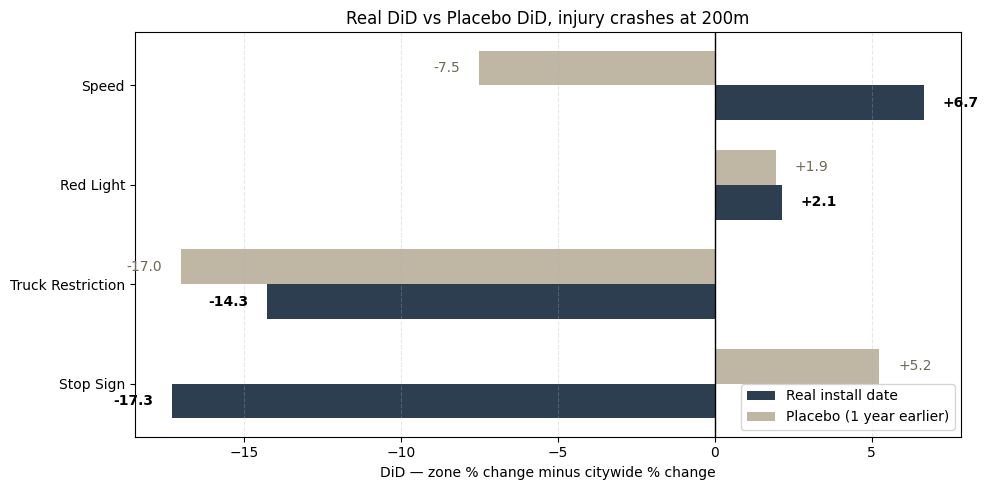

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
types_order = ['Stop Sign', 'Truck Restriction', 'Red Light', 'Speed']

real_dids, placebo_dids = [], []
for t in types_order:
    sub_r = res[res['type']==t]
    sub_p = placebo[placebo['type']==t]
    zr = (sub_r['b200_injury_post'].sum()-sub_r['b200_injury_pre'].sum())/sub_r['b200_injury_pre'].sum()*100
    cr = (sub_r['citywide_injury_post'].sum()-sub_r['citywide_injury_pre'].sum())/sub_r['citywide_injury_pre'].sum()*100
    real_dids.append(zr - cr)
    zp = (sub_p['placebo_injury_post'].sum()-sub_p['placebo_injury_pre'].sum())/sub_p['placebo_injury_pre'].sum()*100
    cp = (sub_p['placebo_city_injury_post'].sum()-sub_p['placebo_city_injury_pre'].sum())/sub_p['placebo_city_injury_pre'].sum()*100
    placebo_dids.append(zp - cp)

y = np.arange(len(types_order))
h = 0.35
ax.barh(y - h/2, real_dids, h, color='#2C3E50', label='Real install date')
ax.barh(y + h/2, placebo_dids, h, color='#BFB7A4', label='Placebo (1 year earlier)')
for i, (r, p) in enumerate(zip(real_dids, placebo_dids)):
    ax.text(r + (0.6 if r >= 0 else -0.6), i - h/2, f'{r:+.1f}',
            va='center', ha='left' if r>=0 else 'right', fontweight='bold')
    ax.text(p + (0.6 if p >= 0 else -0.6), i + h/2, f'{p:+.1f}',
            va='center', ha='left' if p>=0 else 'right', color='#6E6856')

ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(types_order)
ax.set_xlabel('DiD — zone % change minus citywide % change')
ax.set_title('Real DiD vs Placebo DiD, injury crashes at 200m')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x', linestyle='--')
plt.tight_layout()
plt.show()

## What this means for reporting

The honest story is more interesting than "cameras work" or "cameras don't":

1. **Stop Sign cameras show a genuine reduction** in injury crashes beyond the citywide trend. The placebo confirms the effect didn't exist before the cameras. Caveat: n=32 is small, and camera installations often coincide with other streetscape changes (paint, signage) that this analysis can't isolate.

2. **Truck Restriction cameras show a statistical mirage.** The apparent benefit is a pre-existing trend; the cameras didn't cause it. This is a textbook regression-to-the-mean case and a good sidebar for a methods-focused story.

3. **Red Light cameras show no detectable effect** at 200m. Consistent with national literature where rear-end and angle crashes net out.

4. **Speed cameras — the majority of the investment — show no protective effect and possibly a counter-effect.** The mechanism check (speeding vs. non-speeding) confirms the cameras aren't changing driver behavior at the 200m scale. This deserves an explainer, not a gotcha: possible explanations include effects concentrated in a tiny zone (<100m), warning-period delays, placement on corridors where speed isn't the proximate crash cause, or revenue-driven siting.

**Reporting next steps:**
- Confirm with DDOT what `START_DATE` means (active enforcement vs. installed-with-warning-period)
- Visit the specific Stop Sign camera intersections with the biggest drops — what else is different about those locations?
- Request DDOT's site-selection criteria via FOIA
- Re-cut by ward to explore equity dimensions

---

See `outputs/camera_analysis_results.xlsx` for the full per-camera data and all validity checks, and the scripts in `scripts/` for the production pipeline.